# LASSO

In [2]:
# lasso_computation.py
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 days, 10 technical indicators
n_samples, n_features = 1000, 10
X = np.random.randn(n_samples, n_features)  # Features (e.g., RSI, MACD)
y = X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 0.1  # Target: stock returns

# Create feature names
feature_names = [f"Indicator_{i+1}" for i in range(n_features)]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit LASSO model
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_scaled, y)

# Predict and compute MSE
y_pred = lasso.predict(X_scaled)
mse = mean_squared_error(y, y_pred)

# Print results
print("LASSO Regression Results:")
print("Selected features (non-zero coefficients):")
for name, coef in zip(feature_names, lasso.coef_):
    if coef != 0:
        print(f"{name}: {coef:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

LASSO Regression Results:
Selected features (non-zero coefficients):
Indicator_1: 0.4075
Indicator_2: 0.2061
Mean Squared Error: 0.0291


### Plotting

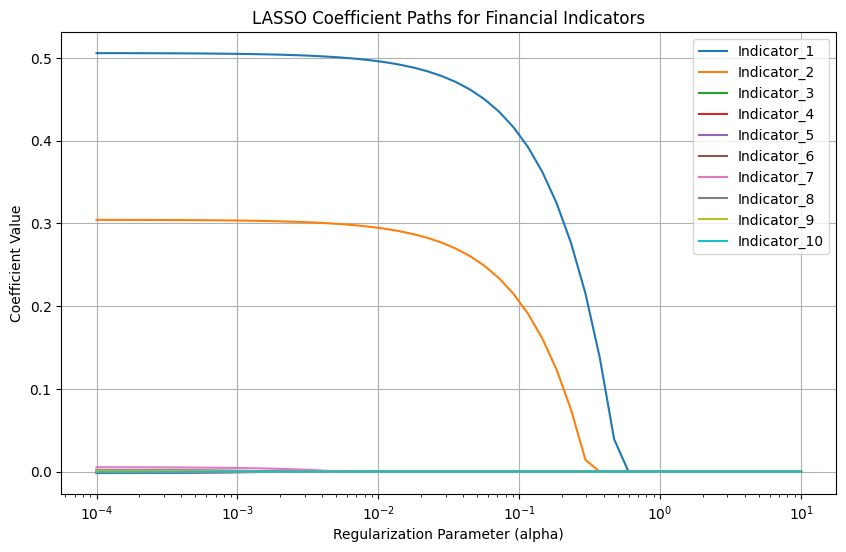

In [4]:
# lasso_illustration.py
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset
n_samples, n_features = 1000, 10
X = np.random.randn(n_samples, n_features)
y = X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 0.1
feature_names = [f"Indicator_{i+1}" for i in range(n_features)]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute coefficient paths for varying alpha
alphas = np.logspace(-4, 1, 50)  # Range of alpha values
coefs = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

# Plot coefficient paths
plt.figure(figsize=(10, 6))
for i in range(n_features):
    plt.plot(alphas, [coef[i] for coef in coefs], label=feature_names[i])
plt.xscale('log')
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Coefficient Value')
plt.title('LASSO Coefficient Paths for Financial Indicators')
plt.legend()
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/lasso_coefficient_paths.png')
plt.show()

# K-Means clustering

k-Means Clustering Results:
Cluster assignments for the first 10 samples: [2 2 2 2 2 2 2 2 2 2]
Centroid coordinates:
Cluster 0: Return=0.306, Volatility=0.410
Cluster 1: Return=0.498, Volatility=0.620
Cluster 2: Return=0.105, Volatility=0.190


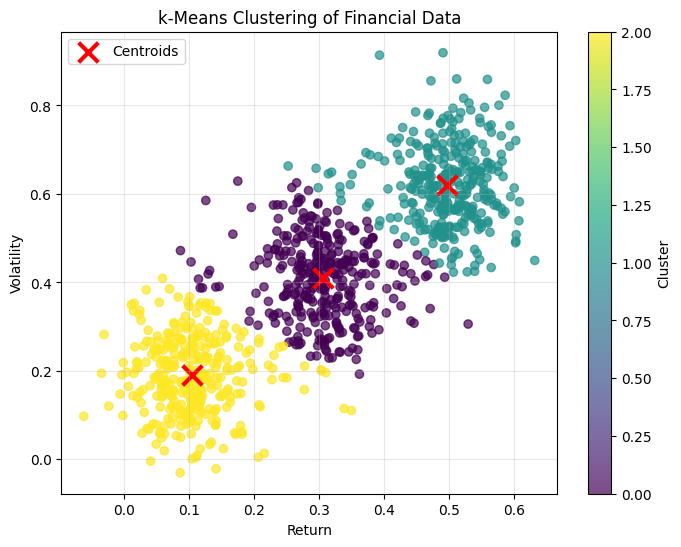

In [13]:
# kmeans_analysis.py
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 stocks, 2 features (return, volatility)
n_samples = 1000
X = np.concatenate([
    np.random.normal([0.1, 0.2], [0.05, 0.1], (333, 2)),  # Cluster 1
    np.random.normal([0.3, 0.4], [0.05, 0.1], (334, 2)),  # Cluster 2
    np.random.normal([0.5, 0.6], [0.05, 0.1], (333, 2))   # Cluster 3
])

feature_names = ["Return", "Volatility"]

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Print computation results
print("k-Means Clustering Results:")
print("Cluster assignments for the first 10 samples:", cluster_labels[:10])
print("Centroid coordinates:")
for i, centroid in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i}: Return={centroid[0]:.3f}, Volatility={centroid[1]:.3f}")

# Generate and save illustration
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.xlabel("Return")
plt.ylabel("Volatility")
plt.title("k-Means Clustering of Financial Data")
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/kmeans_clusters.png', 
           dpi=300, bbox_inches='tight')
plt.show()

# PCA
### Principal Component Analysis



In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Data Generation and Preparation

In [ ]:
# Generate synthetic financial data for demonstration
# This simulates daily returns for 20 stocks over 252 trading days (1 year)

n_stocks = 20
n_days = 252
stock_names = [f'Stock_{i+1}' for i in range(n_stocks)]

# Generate correlated returns data with factor structure
base_returns = np.random.normal(0, 0.02, (n_days, n_stocks))
factor1 = np.random.normal(0, 0.03, n_days).reshape(-1, 1)  # Market factor
factor2 = np.random.normal(0, 0.02, n_days).reshape(-1, 1)  # Style factor
factor3 = np.random.normal(0, 0.015, n_days).reshape(-1, 1) # Sector factor

# Create factor loadings
loadings1 = np.random.uniform(0.3, 0.8, n_stocks)
loadings2 = np.random.uniform(-0.5, 0.5, n_stocks)
loadings3 = np.random.uniform(-0.3, 0.3, n_stocks)

# Generate returns with factor structure
returns_data = (base_returns +
                factor1 @ loadings1.reshape(1, -1) +
                factor2 @ loadings2.reshape(1, -1) +
                factor3 @ loadings3.reshape(1, -1))

# Convert to DataFrame
returns_df = pd.DataFrame(returns_data, columns=stock_names)
print("Sample Financial Returns Data:")
print(returns_df.head())
print(f"\nData shape: {returns_df.shape}")
print(f"\nBasic statistics:")
print(returns_df.describe())

Sample Financial Returns Data:
    Stock_1   Stock_2   Stock_3   Stock_4   Stock_5   Stock_6   Stock_7  \
0  0.029106  0.002565  0.030778  0.054693  0.007475  0.008500  0.034283   
1  0.004173 -0.036030 -0.007859 -0.048699 -0.046545 -0.041176 -0.047682   
2  0.007057  0.003928 -0.018368 -0.028677 -0.039083 -0.013681 -0.005492   
3 -0.020286 -0.017865 -0.031150 -0.040937 -0.004590  0.010274 -0.010674   
4  0.007212  0.021361  0.039481  0.007803  0.005054  0.007261  0.027526   

    Stock_8   Stock_9  Stock_10  Stock_11  Stock_12  Stock_13  Stock_14  \
0  0.039508  0.003870  0.027846 -0.015543  0.000022  0.007765 -0.024825   
1 -0.018632 -0.037325 -0.029479 -0.051022  0.000562 -0.029079 -0.038393   
2  0.001922 -0.006247 -0.043065  0.017779 -0.011538 -0.013839 -0.000061   
3  0.002416 -0.010272 -0.023847 -0.008021  0.012477 -0.015096  0.018822   
4  0.025354  0.007421  0.021994  0.016564  0.037898  0.000277  0.006511   

   Stock_15  Stock_16  Stock_17  Stock_18  Stock_19  Stock_20  
0 -

## 2. Data Standardization

In [ ]:
# Standardize the data (essential for PCA)
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns_df)
returns_scaled_df = pd.DataFrame(returns_scaled, columns=stock_names)

print("Data standardization completed.")
print(f"Mean of standardized data: {np.mean(returns_scaled, axis=0)[:5]}")
print(f"Standard deviation of standardized data: {np.std(returns_scaled, axis=0)[:5]}")

Data standardization completed.
Mean of standardized data: [-3.37031990e-17  1.82834347e-17 -4.95635279e-18 -7.93016446e-18
  1.49791995e-17]
Standard deviation of standardized data: [1. 1. 1. 1. 1.]


## 3. Principal Component Analysis Implementation

In [ ]:
# Apply PCA
pca = PCA(n_components=20)
pca_result = pca.fit_transform(returns_scaled)

# Calculate cumulative explained variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

# Extract eigenvalues and eigenvectors
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

print("PCA Analysis Results:")
print("=" * 60)
print(f"Total number of components: {pca.n_components_}")
print(f"\nExplained variance ratio (first 10 components):")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({pca.explained_variance_ratio_[i]*100:.2f}%)")

print(f"\nCumulative explained variance:")
for i in [2, 4, 6, 8, 10]:
    if i < len(cumulative_var):
        print(f"First {i+1} components: {cumulative_var[i]:.4f} ({cumulative_var[i]*100:.2f}%)")

PCA Analysis Results:
Total number of components: 20

Explained variance ratio (first 10 components):
PC1: 0.4322 (43.22%)
PC2: 0.0715 (7.15%)
PC3: 0.0436 (4.36%)
PC4: 0.0410 (4.10%)
PC5: 0.0392 (3.92%)
PC6: 0.0364 (3.64%)
PC7: 0.0357 (3.57%)
PC8: 0.0325 (3.25%)
PC9: 0.0301 (3.01%)
PC10: 0.0289 (2.89%)

Cumulative explained variance:
First 3 components: 0.5473 (54.73%)
First 5 components: 0.6275 (62.75%)
First 7 components: 0.6996 (69.96%)
First 9 components: 0.7622 (76.22%)
First 11 components: 0.8192 (81.92%)


## 4. Eigenvalue Analysis

In [ ]:
# Kaiser Criterion Analysis
kaiser_components = np.sum(eigenvalues > 1)
print(f"Kaiser Criterion - Components with eigenvalue > 1: {kaiser_components}")

print(f"\nEigenvalues (first 10):")
for i in range(min(10, len(eigenvalues))):
    print(f"λ{i+1}: {eigenvalues[i]:.4f}")

# Variance thresholds
var_80 = np.where(cumulative_var >= 0.80)[0]
var_90 = np.where(cumulative_var >= 0.90)[0]
var_95 = np.where(cumulative_var >= 0.95)[0]

if len(var_80) > 0:
    print(f"\nComponents needed for 80% variance: {var_80[0] + 1}")
if len(var_90) > 0:
    print(f"Components needed for 90% variance: {var_90[0] + 1}")
if len(var_95) > 0:
    print(f"Components needed for 95% variance: {var_95[0] + 1}")

Kaiser Criterion - Components with eigenvalue > 1: 2

Eigenvalues (first 10):
λ1: 8.6794
λ2: 1.4367
λ3: 0.8745
λ4: 0.8231
λ5: 0.7862
λ6: 0.7311
λ7: 0.7167
λ8: 0.6530
λ9: 0.6036
λ10: 0.5795

Components needed for 80% variance: 11
Components needed for 90% variance: 15
Components needed for 95% variance: 17


## 5. Principal Component Loadings Analysis

In [ ]:
# Display PC loadings for interpretation
print("Principal Component Loadings (first 3 PCs, all stocks):")
loadings_df = pd.DataFrame(eigenvectors[:3, :].T,
                          columns=['PC1', 'PC2', 'PC3'],
                          index=stock_names)
print(loadings_df.round(4))

# Identify top contributors to each PC
print("\nTop 5 contributors to each Principal Component:")
for pc_idx in range(3):
    pc_loadings = eigenvectors[pc_idx, :]
    sorted_loadings = sorted(enumerate(pc_loadings), key=lambda x: abs(x[1]), reverse=True)
    print(f"\nPC{pc_idx+1}:")
    for i, (stock_idx, loading) in enumerate(sorted_loadings[:5]):
        print(f"  {stock_names[stock_idx]}: {loading:.4f}")

Principal Component Loadings (first 3 PCs, all stocks):
             PC1     PC2     PC3
Stock_1   0.2048 -0.2403  0.4722
Stock_2   0.2231  0.1424 -0.0989
Stock_3   0.1773 -0.3505 -0.3355
Stock_4   0.2369 -0.2622  0.0849
Stock_5   0.2664  0.0058 -0.1417
Stock_6   0.2471  0.0769 -0.0106
Stock_7   0.1774  0.1824  0.2599
Stock_8   0.2502 -0.1532  0.1373
Stock_9   0.2546  0.1180 -0.1077
Stock_10  0.2171 -0.1647 -0.0738
Stock_11  0.1910  0.4420  0.1443
Stock_12  0.2439  0.0837  0.0260
Stock_13  0.2473  0.1963  0.1221
Stock_14  0.2100 -0.1260 -0.4619
Stock_15  0.2094 -0.2143  0.4281
Stock_16  0.1768  0.4534 -0.0399
Stock_17  0.1821 -0.1480 -0.1572
Stock_18  0.2457  0.0875 -0.0259
Stock_19  0.2365  0.1556 -0.2476
Stock_20  0.2385 -0.2544  0.0499

Top 5 contributors to each Principal Component:

PC1:
  Stock_5: 0.2664
  Stock_9: 0.2546
  Stock_8: 0.2502
  Stock_13: 0.2473
  Stock_6: 0.2471

PC2:
  Stock_16: 0.4534
  Stock_11: 0.4420
  Stock_3: -0.3505
  Stock_4: -0.2622
  Stock_20: -0.2544

PC

## 6. Correlation and Multicollinearity Analysis

In [ ]:
# Correlation analysis
correlation_matrix = returns_df.corr()
avg_correlation = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].mean()

print("Correlation and Multicollinearity Analysis:")
print("=" * 45)
print(f"Average inter-stock correlation: {avg_correlation:.4f}")
print(f"Maximum correlation: {correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].max():.4f}")
print(f"Minimum correlation: {correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].min():.4f}")

# Condition number analysis
condition_number = np.max(eigenvalues) / np.min(eigenvalues[eigenvalues > 1e-10])
print(f"\nCondition number: {condition_number:.2f}")
multicollinearity_level = 'High' if avg_correlation > 0.7 else 'Moderate' if avg_correlation > 0.3 else 'Low'
print(f"Multicollinearity level: {multicollinearity_level}")

Correlation and Multicollinearity Analysis:
Average inter-stock correlation: 0.3955
Maximum correlation: 0.5898
Minimum correlation: 0.1010

Condition number: 28.01
Multicollinearity level: Moderate


## 7. Visualization of Results

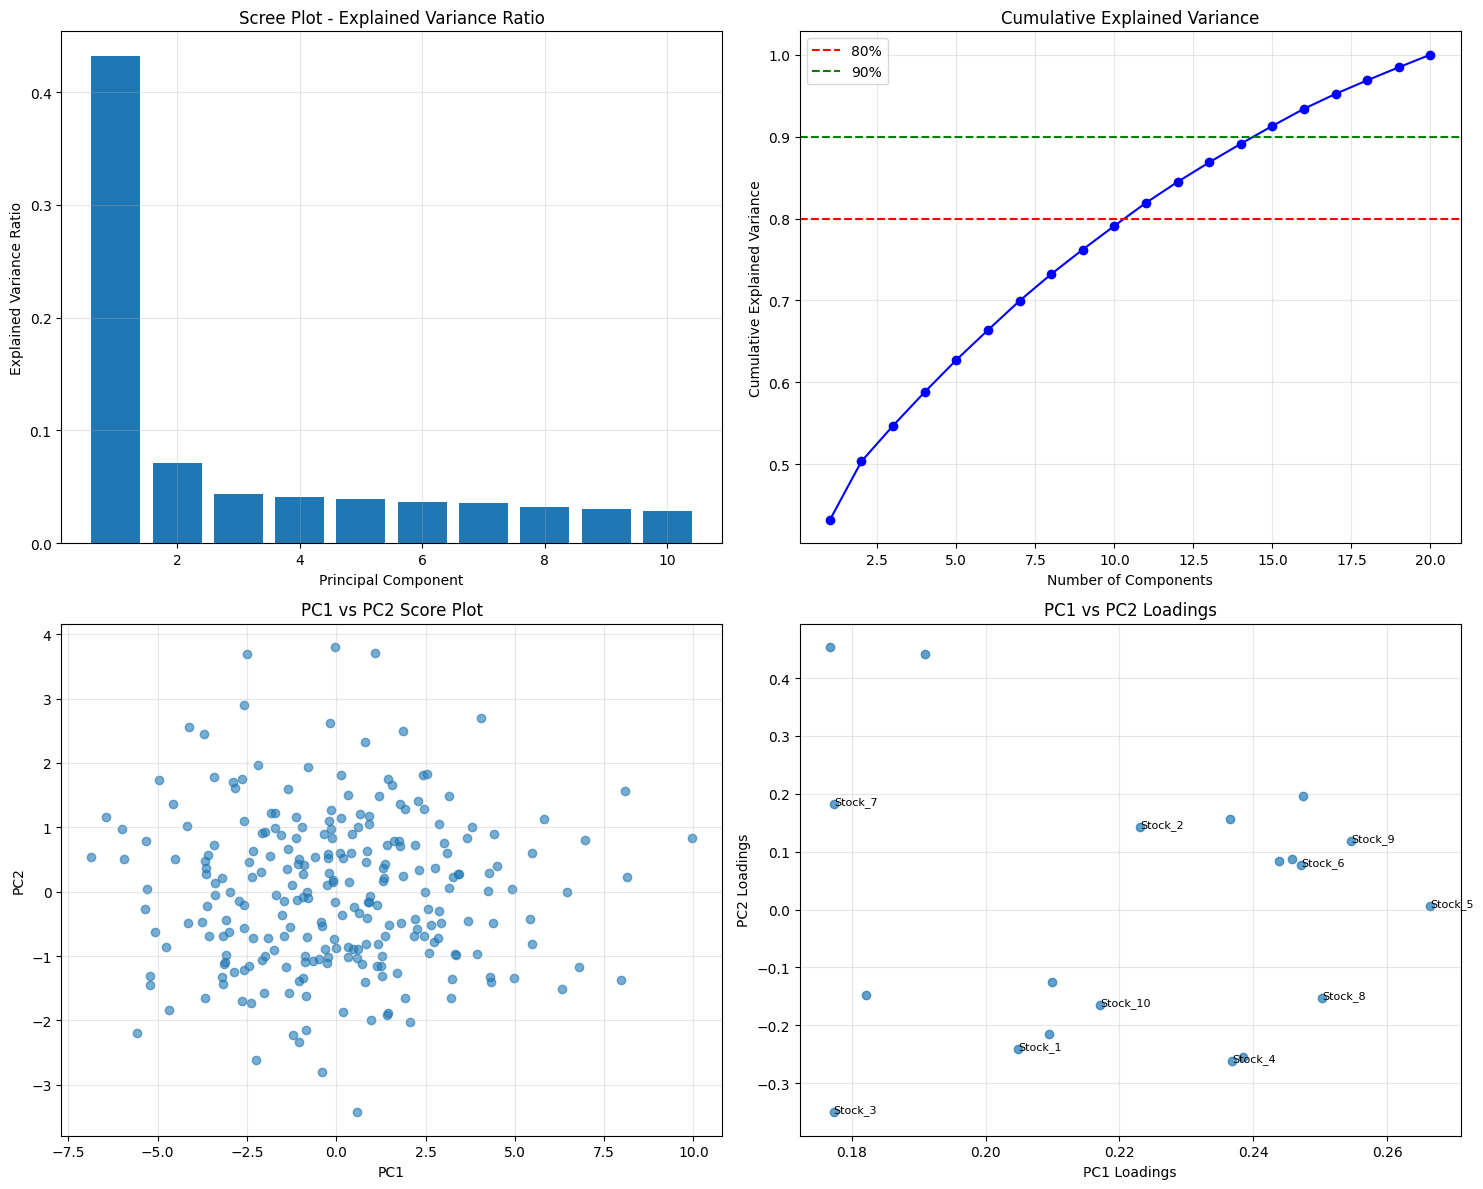

Visualization plots created successfully.


In [ ]:
# Create visualization plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scree plot
ax1.bar(range(1, 11), pca.explained_variance_ratio_[:10])
ax1.set_title('Scree Plot - Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.grid(True, alpha=0.3)

# 2. Cumulative explained variance
ax2.plot(range(1, 21), cumulative_var, 'bo-')
ax2.axhline(y=0.8, color='r', linestyle='--', label='80%')
ax2.axhline(y=0.9, color='g', linestyle='--', label='90%')
ax2.set_title('Cumulative Explained Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. PC1 vs PC2 scatter plot
pc_scores = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(20)])
ax3.scatter(pc_scores['PC1'], pc_scores['PC2'], alpha=0.6)
ax3.set_title('PC1 vs PC2 Score Plot')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.grid(True, alpha=0.3)

# 4. Loading plot for PC1 and PC2
ax4.scatter(eigenvectors[0, :], eigenvectors[1, :], alpha=0.7)
for i, stock in enumerate(stock_names[:10]):  # Show first 10 for readability
    ax4.annotate(stock, (eigenvectors[0, i], eigenvectors[1, i]), fontsize=8)
ax4.set_title('PC1 vs PC2 Loadings')
ax4.set_xlabel('PC1 Loadings')
ax4.set_ylabel('PC2 Loadings')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization plots created successfully.")

## 8. Summary and Conclusions

In [ ]:
print("PCA Analysis Summary:")
print("=" * 30)
print(f" Original dimensions: {returns_df.shape[1]}")
print(f" Effective dimensions (Kaiser rule): {kaiser_components}")
print(f" Dimensionality reduction: {(1-kaiser_components/20)*100:.1f}%")
print(f" Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f" Variance explained by first 3 PCs: {cumulative_var[2]*100:.2f}%")
print(f" Average correlation between assets: {avg_correlation:.4f}")
print(f" Multicollinearity level: {multicollinearity_level}")

print("\nKey Insights:")
print(f"• The first principal component captures {pca.explained_variance_ratio_[0]*100:.1f}% of total variance")
print(f"• {kaiser_components} components have eigenvalues greater than 1 (Kaiser criterion)")
print(f"• PCA reduces dimensionality from {n_stocks} to {kaiser_components} components")
print(f"• The first 3 components explain {cumulative_var[2]*100:.1f}% of total variance")
print(f"• Average correlation suggests {'high' if avg_correlation > 0.7 else 'moderate' if avg_correlation > 0.3 else 'low'} interdependence among assets")

print("\nPCA implementation completed successfully!")

PCA Analysis Summary:
 Original dimensions: 20
 Effective dimensions (Kaiser rule): 2
 Dimensionality reduction: 90.0%
 Variance explained by PC1: 43.22%
 Variance explained by first 3 PCs: 54.73%
 Average correlation between assets: 0.3955
 Multicollinearity level: Moderate

Key Insights:
• The first principal component captures 43.2% of total variance
• 2 components have eigenvalues greater than 1 (Kaiser criterion)
• PCA reduces dimensionality from 20 to 2 components
• The first 3 components explain 54.7% of total variance
• Average correlation suggests moderate interdependence among assets

PCA implementation completed successfully!


## References

1. Jolliffe, I. T. (2002). Principal Component Analysis, Second Edition. Springer-Verlag.
2. Fabozzi, F. J., Focardi, S. M., & Kolm, P. N. (2010). Quantitative Equity Investing. Wiley.
3. Celestin, P. (2025). Principal Component Analysis For Simplifying Multivariate Financial Data In Portfolio Risk Analysis. SSRN Electronic Journal.

# Classification trees

Classification Tree Results:
Accuracy on test set: 1.0000
Sample predictions for the first 5 test samples: [0 0 0 0 0]


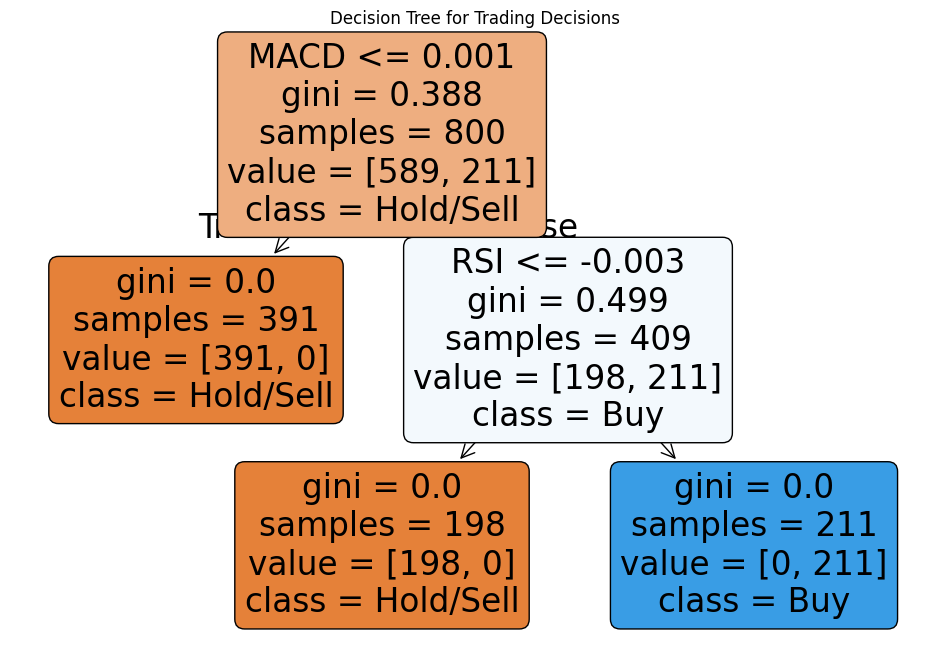

In [15]:
# classification_trees_analysis.py
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 days, 4 features (e.g., RSI, MACD, volume, price)
n_samples = 1000
X = np.random.randn(n_samples, 4)  # Features: RSI, MACD, volume, price
y = (X[:, 0] > 0) & (X[:, 1] > 0)  # Simple rule: buy if RSI and MACD positive, else hold/sell
y = np.where(y, 1, 0)  # Binary classification: 1 (buy), 0 (hold/sell)
feature_names = ["RSI", "MACD", "Volume", "Price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply classification tree
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Predict and evaluate
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Print computation results
print("Classification Tree Results:")
print(f"Accuracy on test set: {accuracy:.4f}")
print("Sample predictions for the first 5 test samples:", y_pred[:5])

# Generate and save illustration: Decision tree diagram
plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=feature_names, class_names=["Hold/Sell", "Buy"], filled=True, rounded=True)
plt.title("Decision Tree for Trading Decisions")
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/classification_tree.png')
plt.show()